In [3]:
import pandas            as pd
import xarray            as xr
import matplotlib.pyplot as plt

from pathlib            import Path
from datetime           import datetime
from matplotlib.patches import Rectangle

In [4]:
""" Patch Catalog """

catalog = pd.DataFrame({

    "spacecraft": [
        "Solar Orbiter",
    ],

    "interval": [
        "SolO 1",
    ],

    "date_start": [
        datetime(2025, 3, 17, 00, 00, 00),
        # ...
    ],

    "date_end": [
        datetime(2025, 4, 13, 00, 00, 00),
        # ...
    ],

    "r_min": [
        0.29,
    ],

    "r_max": [
        0.42,
    ],
})

# --- Convert dates to datetime
catalog["date_start"] = pd.to_datetime(catalog["date_start"])
catalog["date_end"] = pd.to_datetime(catalog["date_end"])

# --- Save catalog to netcdf
ds = xr.Dataset.from_dataframe(catalog.set_index("interval"))

catalog_path = Path("patch_catalog.nc")

ds.to_netcdf(catalog_path)

print(ds)

<xarray.Dataset> Size: 48B
Dimensions:     (interval: 1)
Coordinates:
  * interval    (interval) object 8B 'SolO 1'
Data variables:
    spacecraft  (interval) object 8B 'Solar Orbiter'
    date_start  (interval) datetime64[ns] 8B 2025-03-17
    date_end    (interval) datetime64[ns] 8B 2025-04-13
    r_min       (interval) float64 8B 0.29
    r_max       (interval) float64 8B 0.42


In [7]:
catalog_path = "patch_catalog.nc"

ds = xr.open_dataset(catalog_path)

print(ds)

<xarray.Dataset> Size: 108B
Dimensions:     (interval: 1)
Coordinates:
  * interval    (interval) <U6 24B 'SolO 1'
Data variables:
    spacecraft  (interval) <U13 52B ...
    date_start  (interval) datetime64[ns] 8B ...
    date_end    (interval) datetime64[ns] 8B ...
    r_min       (interval) float64 8B ...
    r_max       (interval) float64 8B ...


In [9]:
for interval in ds.interval.values:

    spacecraft = ds.spacecraft.sel(interval=interval).item()
    date_start = ds.date_start.sel(interval=interval).values
    date_end = ds.date_end.sel(interval=interval).values
    r_min = ds.r_min.sel(interval=interval).item()
    r_max = ds.r_max.sel(interval=interval).item()

    print(
        spacecraft,
        interval,
        date_start,
        date_end,
        r_min,
        r_max
    )

Solar Orbiter SolO 1 2025-03-17T00:00:00.000000000 2025-04-13T00:00:00.000000000 0.29 0.42


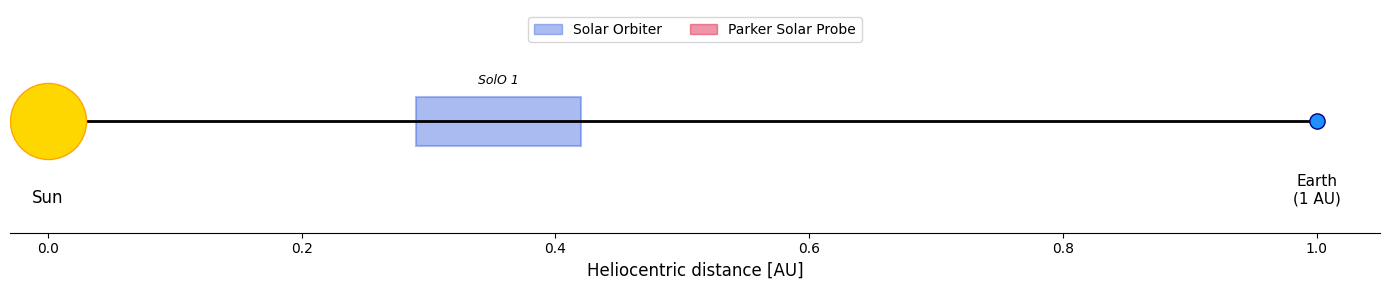

In [11]:
# Load catalog

ds = xr.open_dataset("patch_catalog.nc")

# Figure

fig, ax = plt.subplots(figsize=(14, 3))


# Main horizontal axis (Sun -> Earth)

ax.hlines(
    y=0,
    xmin=0,
    xmax=1.0,
    color="black",
    linewidth=2
)

# Catalog intervals

for interval in ds.interval.values:

    spacecraft = ds.spacecraft.sel(interval=interval).item()

    rmin = ds.r_min.sel(interval=interval).item()
    rmax = ds.r_max.sel(interval=interval).item()

    if spacecraft == "Solar Orbiter":

        color = "royalblue"

    elif spacecraft == "Parker Solar Probe":

        color = "crimson"

    else:

        raise ValueError(
            f"Unknown spacecraft: {spacecraft}"
        )


    # Interval
    rect = Rectangle(
        (rmin, -0.1),
        rmax - rmin,
        0.2,
        facecolor=color,
        edgecolor=color,
        alpha=0.45,
        linewidth=1.5
    )

    ax.add_patch(rect)


    # Label
    ax.text(
        (rmin + rmax) / 2,
        0.14,
        interval,
        ha="center",
        va="bottom",
        fontsize=9,
        fontstyle="italic",
        color="black"
    )

# Sun

ax.scatter(
    0,
    0,
    s=3000,
    color="gold",
    edgecolor="orange",
    zorder=10
)

ax.text(
    0,
    -0.33,
    "Sun",
    ha="center",
    fontsize=12
)

# Earth

ax.scatter(
    1.0,
    0,
    s=120,
    color="dodgerblue",
    edgecolor="navy",
    zorder=10
)

ax.text(
    1.0,
    -0.33,
    "Earth\n(1 AU)",
    ha="center",
    fontsize=11
)

# Formatting

ax.set_xlim(-0.03, 1.05)
ax.set_ylim(-0.45, 0.45)

ax.set_xlabel(
    "Heliocentric distance [AU]",
    fontsize=12
)

ax.set_yticks([])

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Legend

handles = [
    Rectangle(
        (0, 0),
        1,
        1,
        color="royalblue",
        alpha=0.45
    ),

    Rectangle(
        (0, 0),
        1,
        1,
        color="crimson",
        alpha=0.45
    )
]

labels = [
    "Solar Orbiter",
    "Parker Solar Probe"
]

ax.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)


plt.tight_layout()

plt.savefig(
    "timeline.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()